#RETO 3 - CLASIFICACIÓN KNN Y CLUSTERIZACIÓN CON KMEANS

##1. Importación de Datos

In [41]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

#Importo el archivo
solicitantes = pd.read_excel('/content/drive/MyDrive/Eafit Analítica/3. Vacation_Data.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
solicitantes.head()

,Own,Children,Age,Income,Rental
0,0,1,41,64000,0
1,1,0,64,22000,0
2,1,1,38,189000,1
3,0,1,36,94000,0
4,0,1,79,150000,0


##2. Limpieza de Datos

In [43]:
solicitantes.shape

(820, 5)

In [44]:
#Elimino las filas donde 'Rental' está vacío
AAA = solicitantes.dropna(subset=['Rental'])

In [45]:
AAA.shape

(820, 5)

In [46]:
#Inspección de la variable
print(AAA.groupby('Rental').size())

Rental
0    513
1    307
dtype: int64


En este caso se puede ver que la base de datos está completa entonces no se necesita hacer limpieza de datos.

##3. Descripción de las Variables

Para este caso, se busca determinar si la persona rentará o no una casa durante la temporada de vacaciones. Teniendo esto en cuenta, la variable dependiente de la base de datos sería 'Rental'

Nora Jackson trabajo con un consorcio de casa vacacionales de alquiler y necesita recopilar un conjunto de datos o información para determinar por medio de un modelo si un cliete rentará o no la casa.  

**Descripción de las variables y que significan para el problema de negocio: **   
Own:** Si el cliente potencial es dueño de una casa (o sig no y 1 si)   
**Children:** Si el cliente tiene hijo (0 no y 1 si)    
**Age:** La edad del cliente en años   
**Income:** Los ingresos anuales del cliente  
**Rental:** Si el cliente ha alquilado previamente una casa frente al mar (0 no y 1 si)  

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


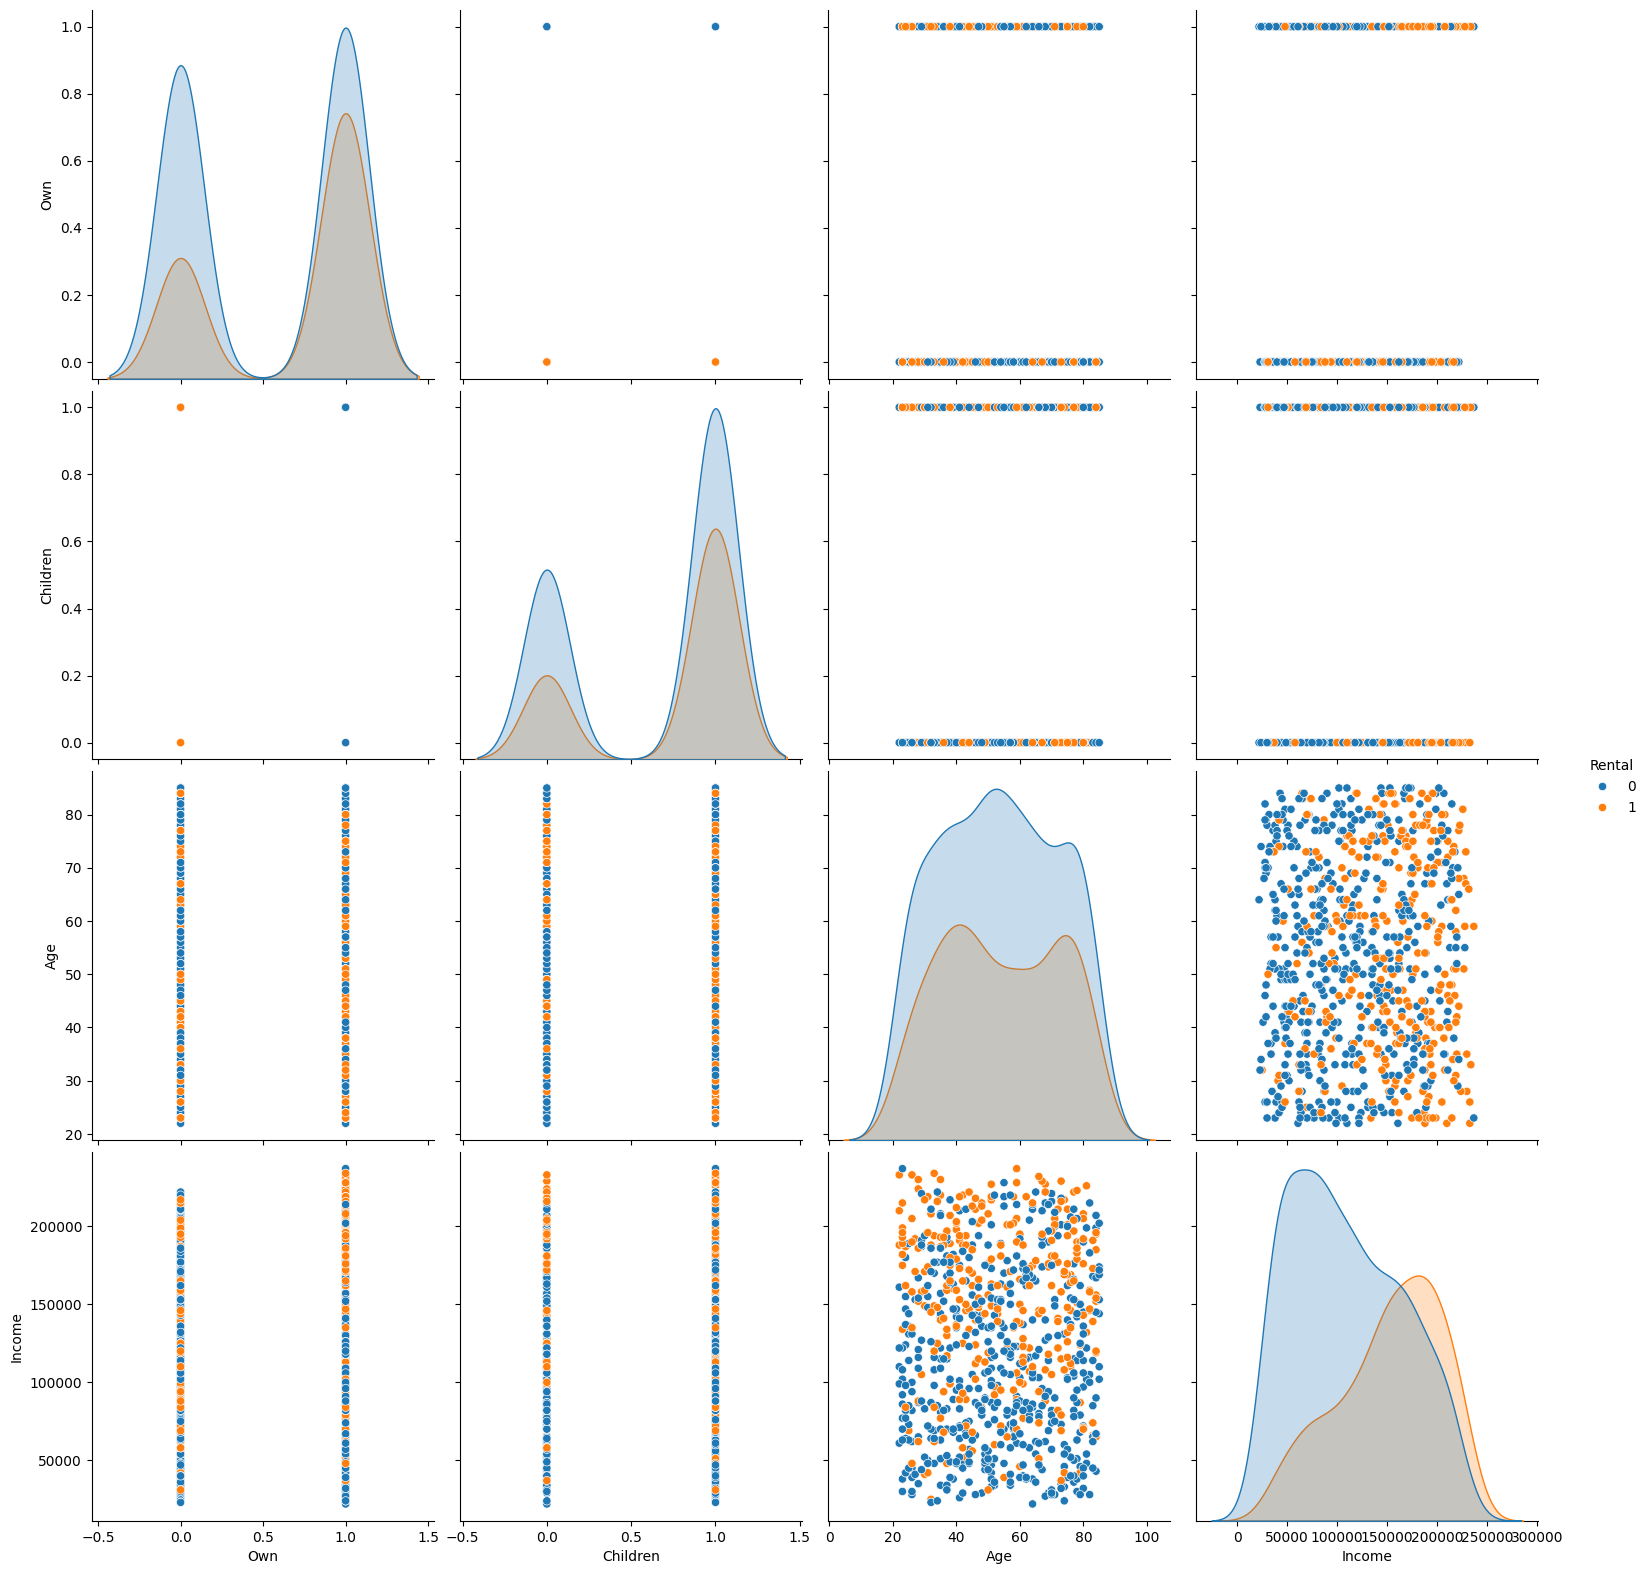

In [47]:
import seaborn as sns
sns.pairplot(AAA, hue='Rental', size=4, vars=['Own','Children', 'Age', 'Income'])

In [48]:
#Escojo las variables independientes del modelo, osea 'Own','Children', 'Age', 'Income'
XD = AAA[['Own','Children', 'Age', 'Income']]

In [49]:
#Escojo la variable dependiente
yd = solicitantes['Rental'].dropna()

In [50]:
yd.shape

(820,)

In [51]:
import numpy as np
# Construimos la matriz de correlación de las variables independientes
dfinf = pd.DataFrame(np.column_stack((XD,yd)))
dfinf.columns=['Own','Children', 'Age', 'Income','Rental']
mCorr = dfinf.corr()
mCorr

,Own,Children,Age,Income,Rental
Own,1.000000,0.042532,0.067497,0.040827,0.156361
Children,0.042532,1.000000,-0.039087,-0.028243,0.086952
Age,0.067497,-0.039087,1.000000,0.005616,0.017890
Income,0.040827,-0.028243,0.005616,1.000000,0.355934
Rental,0.156361,0.086952,0.017890,0.355934,1.000000


<Axes: >

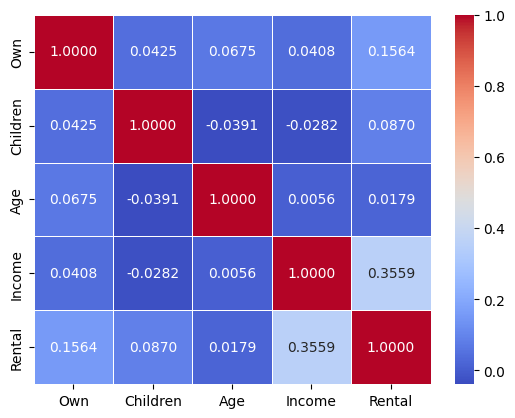

In [52]:
#Construimos la tabla de la Matriz de Correlación
sns.heatmap(mCorr, cmap='coolwarm', linewidth=0.5, annot=True, fmt='.4f')

De acuerdo a los resultados obtenidos de la tabla, se puede observar que la variable con mejor proceso de caracterización es 'Income' y las variables de entrada y salida con mayor correlación son 'Income' y 'Rental'.

In [53]:
#Exportación de la matriz de correlación
dfCorrel = pd.DataFrame(mCorr)
dfCorrel.to_excel('InformeCorrel.xlsx')


##4.Implementación del Modelo KNN

In [54]:
#Convierto los datasets a arrays
XDArray = np.array(XD, dtype=float)
ydArray = np.array(yd, dtype=float)

In [55]:
from sklearn.neighbors import KNeighborsClassifier

#Creo la variable que aloja el modelo
knnModel = KNeighborsClassifier(n_neighbors=10)

In [56]:
#Entreno el modelo
knnModel.fit(XDArray, ydArray)

KNeighborsClassifier(n_neighbors=10)

In [57]:
#Predecimos los yd
ydPred = knnModel.predict(XDArray)
ydPred

array([0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
       0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0.,
       0., 1., 0., 0., 1.

##5. Métricas de Evaluación del Modelo

In [58]:
from sklearn.metrics import confusion_matrix

In [59]:
from sklearn.metrics import roc_auc_score
roc_auc_score(ydArray, ydPred)

0.6415382466299662

In [60]:
#Creo la Matriz de Confusión
cm = confusion_matrix(yd, ydPred)
cm

array([[446,  67],
       [180, 127]])

In [61]:
#Exactitud (Accuracy)
print(f'La exactitud del modelos es del {(cm[1][1]+cm[0][0])/cm.sum():.2%}')

La exactitud del modelos es del 69.88%


La exactitud representa el porcentaje de predicciones correctas realizadas por el modelo. En este caso el modelo tiene un porcentaje de exactitud aceptable no es muy alta, pero tampoco muy bajo (69.88%)

In [62]:
#Sencibilidad o exhaustividad o recall
print(f'La sencibilidad del modelo es del {cm[1][1]/(cm[1][1]+cm[1][0]):.2%}')

La sencibilidad del modelo es del 41.37%


Esta mide porcentaje de casos positivos que el modelo identifica correctamente.se puede ver que el porcentaje fue del 41.37%, resultado más bajo que el de la precisión.

In [63]:
#La especificidad
print(f'La especificidad del modelo es del {cm[0][0]/(cm[0][0]+cm[0][1]):.2%}')

La especificidad del modelo es del 86.94%


La especificidad mide el porcentaje de casos negativos que el modelo clasifica correctamente como negativos. osea, nos muestra qué tan bien el modelo puede identificar los casos que no pertenecen a una determinada clase.

In [64]:
#Precisión
print(f'La precisión del modelo es del {cm[1][1]/(cm[1][1]+cm[0][1]):.2%}')

La precisión del modelo es del 65.46%


La precisión se refiere al porcentaje de predicciones positvas que resultaron ser correctas. En este caso fue de 65.46%

In [65]:
#Tasa de error
print(f'La tasa de error del modelo es del {1-(cm[1][1]+cm[0][0])/cm.sum():.2%}')

La tasa de error del modelo es del 30.12%


La tasa de error mide el porcentaje de predicciones incorrectas realizadas por el modelo. En este caso fue de 30.12%

##6. Pronóstico con un solo solicitante

In [66]:
XDi = np.array([(0, 0, 58, 83931)])
ydi = knnModel.predict(XDi)

print(f'La decisión frente a la renta es:{ydi}')

La decisión frente a la renta es:[0.]


Esto significa que el pronóstico para el cliente evaluado es que NO rentará la casa en esta temporada de vacaciones

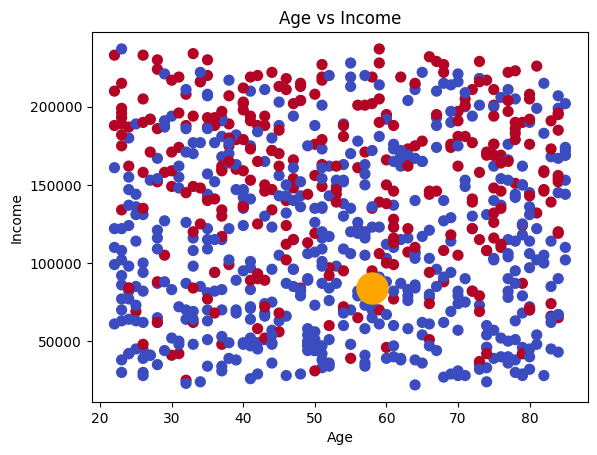

In [67]:
#Ubicamos a este solicitante en la gráfica de Age vs Income
import matplotlib.pyplot as plt
plt.scatter(XDArray[:,2], XDArray[:,3], c=ydArray, s=50, cmap='coolwarm')
plt.scatter(XDi[:,2], XDi[:,3], marker='o', s=500, facecolor='orange')
plt.title('Age vs Income')
plt.xlabel('Age'); plt.ylabel('Income')
plt.show()

##7. Clusterización con KMeans

In [68]:
from sklearn.cluster import KMeans

In [69]:
#Creamos la variable que aloja el modelo
np.random.seed(42)
#Definimos la cantidad de clusters que vamos a crear
k=5
kMeansModel = KMeans(n_clusters=k, init='random', random_state=42)

##ENTRENAMOS EL MODELO
kMeansModel.fit(XDArray, yd)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(init='random', n_clusters=5, random_state=42)

In [70]:
#Tomamos un solicitante y analizamos en que cluster se ubica
labels = kMeansModel.labels_
centroids = kMeansModel.cluster_centers_

XDi = np.array([(0, 0, 58, 83931)])
ydi = kMeansModel.predict(XDi)

print(f'Este solicitante de renta pertenece al cluster {ydi}')

Este solicitante de renta pertenece al cluster [1]


Esto significa que el cliente evaluado pertenece al cluster 2 con índice 1

In [71]:
centroids

array([[6.11111111e-01, 6.41414141e-01, 5.46414141e+01, 1.60146465e+05],
       [5.48192771e-01, 7.04819277e-01, 5.21626506e+01, 7.79518072e+04],
       [5.76923077e-01, 7.30769231e-01, 5.37307692e+01, 4.17769231e+04],
       [6.09467456e-01, 7.10059172e-01, 5.30118343e+01, 2.04828402e+05],
       [5.85987261e-01, 6.30573248e-01, 5.43821656e+01, 1.17707006e+05]])

Cada columna representa una variable, osea, [Own, Children, Age, Income] y se cuenta 0, 1, 2, 3.  

Las filas representan los Clusters y se cuenta 1, 2, 3, 4, 5

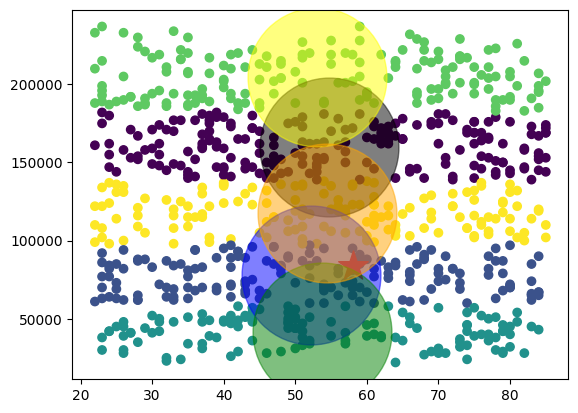

In [72]:
#Graficamos los clusters y al cliente en específico

#El 2 signica Age y el 3 significa Income, que son las variables que estamos utilizando para la gráfica
plt.scatter(XDArray[:,2], XDArray[:,3], c=labels)
plt.scatter(XDi[:,2], XDi[:,3], marker='*', s=500, facecolor='red')
plt.scatter(centroids[0,2], centroids[0,3], marker='o', s=10000, alpha=0.5, facecolor='black')
plt.scatter(centroids[1,2], centroids[1,3], marker='o', s=10000, alpha=0.5, facecolor='blue')
plt.scatter(centroids[2,2], centroids[2,3], marker='o', s=10000, alpha=0.5, facecolor='green')
plt.scatter(centroids[3,2], centroids[3,3], marker='o', s=10000, alpha=0.5, facecolor='yellow')
plt.scatter(centroids[4,2], centroids[4,3], marker='o', s=10000, alpha=0.5, facecolor='orange')

El cliente evaluado está ubicado en el cluster 2 con índice 1

In [73]:
AAA.loc[:,'cluster'] = labels

counts_1 = np.bincount(labels)
count_2 = AAA.groupby('cluster').agg({'Rental': lambda x:(x==0).sum()})
count_3 = AAA.groupby('cluster').agg({'Rental': lambda x:(x==1).sum()})

#Esto muestra en cada cluster cuantos rentarán la casa y cuantos no rentarán, osea o y 1
df = pd.DataFrame(np.column_stack((count_2, count_3 )))
df

,0,1
0,99,99
1,127,39
2,113,17
3,66,103
4,108,49


De acuerdo a esta tabla:



*   En el cluster 1 con índice 0 rentarán 99 personas
*   En el cluster 2 con índice 1 rentarán 39 personas
*   En el cluster 3 con índice 2 rentarán 17 personas
*   En el cluster 4 con índice 3 rentarán 103 personas
*   En el cluster 5 con índice 4 rentarán 49 personas

En base a esta información el cluster con mayor número de personas para arrendar la casa en vaciones es el cluster 4 con índice 3



In [74]:
#Resumen de estadística descriptiva para el cluster 0
AAA[AAA['cluster']==0][['Own','Children', 'Age', 'Income']]

,Own,Children,Age,Income
4,0,1,79,150000
5,1,1,39,179000
8,1,0,78,142000
10,0,1,57,150000
13,1,1,64,175000
...,...,...,...,...
810,0,1,30,159000
812,0,1,31,162000
813,1,1,54,153000
814,1,0,54,152000


In [75]:
#Resumen de estadística descriptiva para el cluster 0
AAA[AAA['cluster']==0][['Own','Children', 'Age', 'Income']].describe()

,Own,Children,Age,Income
count,198.000000,198.000000,198.000000,198.000000
mean,0.611111,0.641414,54.641414,160146.464646
std,0.488734,0.480801,18.190411,12594.163608
min,0.000000,0.000000,22.000000,139000.000000
25%,0.000000,0.000000,39.000000,149000.000000
50%,1.000000,1.000000,53.000000,161500.000000
75%,1.000000,1.000000,71.000000,171000.000000
max,1.000000,1.000000,85.000000,182000.000000


Mean significa promedio

In [76]:
#Para ver los promedios de las edades de cada cluster comparadas
AAA.groupby(['cluster'])['Age'].mean()

,Age
cluster,
0,54.641414
1,52.162651
2,53.730769
3,53.011834
4,54.382166


El cluster que presenta la mayor edad promedio es el cluster 1 con índice 0

In [77]:
AAA.groupby(['cluster'])['Children'].mean()

,Children
cluster,
0,0.641414
1,0.704819
2,0.730769
3,0.710059
4,0.630573


El cluster que presenta la mayor cantidad de clientes con hijos es el cluster 3 con índice 2

In [78]:
AAA.groupby(['cluster'])['Own'].mean()

,Own
cluster,
0,0.611111
1,0.548193
2,0.576923
3,0.609467
4,0.585987


El cluster que presenta la menor cantidad de propietarios es el cluster 2 con índie 1

In [79]:
AAA.groupby(['cluster'])['Income'].mean()

,Income
cluster,
0,160146.464646
1,77951.807229
2,41776.923077
3,204828.402367
4,117707.006369


El cluster que presenta los mayores ingresos es el cluster 4 con índice 3

In [80]:
#Promedio de cada cluster para cada variable, solo para los que rentarán
AAA[AAA['Rental']==0].groupby(['cluster']).agg({'Own':'mean', 'Children':'mean', 'Age':'mean', 'Income':'mean'})

,Own,Children,Age,Income
cluster,,,,
0,0.484848,0.575758,53.454545,159868.686869
1,0.559055,0.637795,51.645669,77685.039370
2,0.557522,0.734513,54.150442,41415.929204
3,0.439394,0.696970,55.439394,203484.848485
4,0.555556,0.611111,53.175926,116870.370370
